<a href="https://colab.research.google.com/github/abhaykatiyar023-ak/House-Price-Prediction/blob/main/RNN_IMDb_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARIEs

In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

Check TensorFlow Version and GPU

In [29]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU Available:", gpus)
    print("GPU Name:", tf.test.gpu_device_name())
else:
    print("GPU Not Available")

print("CUDA Built:", tf.test.is_built_with_cuda())

TensorFlow Version: 2.20.0
GPU Not Available
CUDA Built: True


Load IMDb Dataset

In [30]:
VOCAB_SIZE = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nSample encoded review:")
print(X_train[0])

print("\nSample label:")
print(y_train[0])

Training samples: 25000
Testing samples: 25000

Sample encoded review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19

Understand the Dataset

In [31]:
print("Number of reviews:", len(X_train) + len(X_test))
print("Vocabulary size:", VOCAB_SIZE)

print("\nFirst encoded review:")
print(X_train[0])

print("\nSentiment label:")
print(y_train[0])

Number of reviews: 50000
Vocabulary size: 10000

First encoded review:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19

You can also check review lengths:

In [32]:
review_lengths = [len(review) for review in X_train]

print("Minimum review length:", min(review_lengths))
print("Maximum review length:", max(review_lengths))
print("Average review length:", np.mean(review_lengths))

Minimum review length: 11
Maximum review length: 2494
Average review length: 238.71364


5. Sequence Padding

In [33]:
MAX_LENGTH = 200

In [34]:
X_train_pad = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)

X_train shape: (25000, 200)
X_test shape: (25000, 200)


6. Build RNN Model

In [35]:
def create_rnn_model(rnn_units):

    model = Sequential([
        Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=128,
            input_length=MAX_LENGTH
        ),

        SimpleRNN(rnn_units),

        Dense(64, activation='relu'),

        Dense(1, activation='sigmoid')
    ])

    return model

7. Create Model with 32 RNN Units

In [36]:
model = create_rnn_model(32)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

8. Compile Model

In [37]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

9. Train Model

In [38]:
start_time = time.time()

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20,
    verbose=1
)

training_time = time.time() - start_time

print("\nTraining Time:", training_time, "seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 84ms/step - accuracy: 0.4963 - loss: 0.6945 - val_accuracy: 0.5048 - val_loss: 0.6933
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.6244 - loss: 0.6263 - val_accuracy: 0.5036 - val_loss: 0.7432
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.7372 - loss: 0.4216 - val_accuracy: 0.5072 - val_loss: 0.9436
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.7805 - loss: 0.3543 - val_accuracy: 0.5082 - val_loss: 1.2002
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.8058 - loss: 0.3296 - val_accuracy: 0.5136 - val_loss: 1.3564

Training Time: 177.06375789642334 seconds


10. Plot Training Accuracy

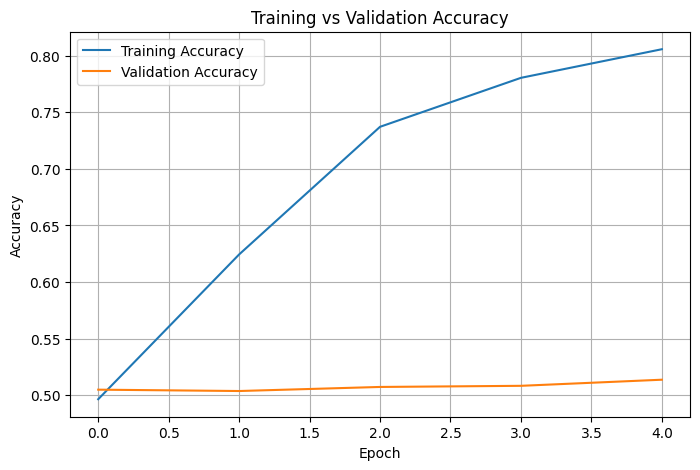

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

11. Plot Training Loss

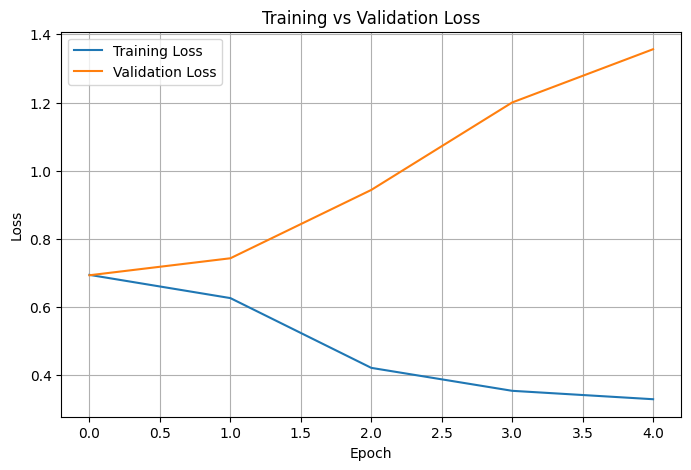

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

12. Evaluate Model

In [41]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4988 - loss: 1.3359

Test Loss: 1.3358951807022095
Test Accuracy: 0.49876001477241516


In [42]:
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

Test Accuracy: 49.88%


13. Custom Movie Review Prediction

In [43]:
word_index = imdb.get_word_index()

create a function


In [44]:
def encode_review(text):

    words = text.lower().split()

    encoded = []

    for word in words:

        index = word_index.get(word)

        if index is not None:
            index += 3

            if index < VOCAB_SIZE:
                encoded.append(index)

    return pad_sequences(
        [encoded],
        maxlen=MAX_LENGTH,
        padding='post',
        truncating='post'
    )

now predict function

In [45]:
def predict_sentiment(review):

    encoded_review = encode_review(review)

    probability = model.predict(
        encoded_review,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", review)
    print("Predicted Probability:", probability)
    print("Predicted Class:", sentiment)

test positive review

In [46]:
predict_sentiment(
    "The movie was absolutely amazing and I really enjoyed it"
)

Review: The movie was absolutely amazing and I really enjoyed it
Predicted Probability: 0.4481551
Predicted Class: Negative


test negative review

In [47]:
predict_sentiment(
    "The movie was boring and a complete waste of time"
)

Review: The movie was boring and a complete waste of time
Predicted Probability: 0.5633633
Predicted Class: Positive


14. Hyperparameter Experiments

In [48]:
experiments = [
    {"units": 32, "epochs": 5},
    {"units": 64, "epochs": 5},
    {"units": 128, "epochs": 5}
]

results = []

for experiment in experiments:

    units = experiment["units"]
    epochs = experiment["epochs"]

    print("\n" + "=" * 50)
    print(f"Experiment: SimpleRNN Units = {units}")
    print("=" * 50)

    model_exp = create_rnn_model(units)

    model_exp.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()

    history_exp = model_exp.fit(
        X_train_pad,
        y_train,
        epochs=epochs,
        batch_size=64,
        validation_split=0.20,
        verbose=1
    )

    training_time = time.time() - start_time

    test_loss_exp, test_accuracy_exp = model_exp.evaluate(
        X_test_pad,
        y_test,
        verbose=0
    )

    train_accuracy = history_exp.history['accuracy'][-1]
    validation_accuracy = history_exp.history['val_accuracy'][-1]

    parameters = model_exp.count_params()

    results.append({
        "RNN Units": units,
        "Epochs": epochs,
        "Training Accuracy": train_accuracy,
        "Validation Accuracy": validation_accuracy,
        "Test Accuracy": test_accuracy_exp,
        "Parameters": parameters,
        "Training Time (sec)": training_time
    })


Experiment: SimpleRNN Units = 32
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 84ms/step - accuracy: 0.5177 - loss: 0.6932 - val_accuracy: 0.5094 - val_loss: 0.6965
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.5976 - loss: 0.6466 - val_accuracy: 0.5562 - val_loss: 0.6886
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.6834 - loss: 0.4980 - val_accuracy: 0.5328 - val_loss: 0.8169
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.7282 - loss: 0.3959 - val_accuracy: 0.5352 - val_loss: 0.9905
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 83ms/step - accuracy: 0.7542 - loss: 0.3671 - val_accuracy: 0.5404 - val_loss: 1.0635

Experiment: SimpleRNN Units = 64
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - accuracy: 0.5007 - loss: 0.7005 - val_accuracy: 0.4922 - val_loss: 0.6956
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.5059 - loss: 0.6951 - val_accuracy: 0.5138 - val_loss: 0.6924
Epoch 3/5
313/313 ━━━━━━━━━━━

15. Comparison Table

In [49]:
results_df = pd.DataFrame(results)

print("\nFinal Comparison:")
display(results_df)


Final Comparison:


,RNN Units,Epochs,Training Accuracy,Validation Accuracy,Test Accuracy,Parameters,Training Time (sec)
0,32,5,0.75420,0.5404,0.53220,1287329,177.379584
1,64,5,0.63475,0.5512,0.53720,1296577,185.440478
2,128,5,0.56970,0.5008,0.50864,1321217,255.346978


In [50]:
results_df.style.format({
    "Training Accuracy": "{:.4f}",
    "Validation Accuracy": "{:.4f}",
    "Test Accuracy": "{:.4f}",
    "Training Time (sec)": "{:.2f}"
})

,RNN Units,Epochs,Training Accuracy,Validation Accuracy,Test Accuracy,Parameters,Training Time (sec)
0,32,5,0.7542,0.5404,0.5322,1287329,177.38
1,64,5,0.6348,0.5512,0.5372,1296577,185.44
2,128,5,0.5697,0.5008,0.5086,1321217,255.35


16. Compare Test Accuracy

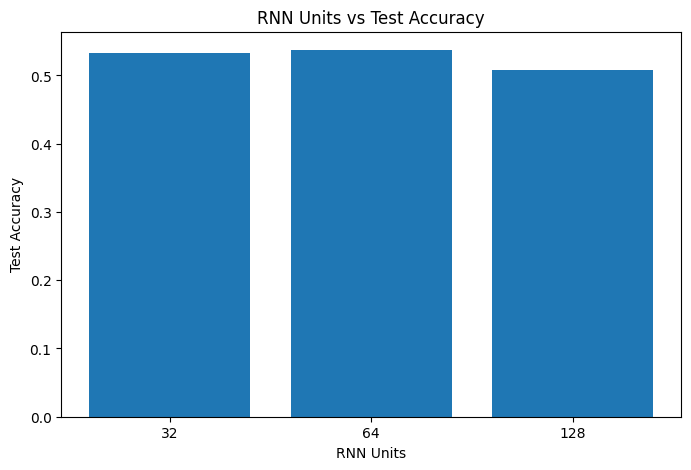

In [51]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["RNN Units"].astype(str),
    results_df["Test Accuracy"]
)

plt.xlabel("RNN Units")
plt.ylabel("Test Accuracy")
plt.title("RNN Units vs Test Accuracy")

plt.show()

17. Find Best Model

In [52]:
best_model = results_df.loc[
    results_df["Test Accuracy"].idxmax()
]

print("Best Model")
print("RNN Units:", best_model["RNN Units"])
print("Test Accuracy:", best_model["Test Accuracy"])
print("Parameters:", best_model["Parameters"])
print("Training Time:", best_model["Training Time (sec)"])

Best Model
RNN Units: 64.0
Test Accuracy: 0.5371999740600586
Parameters: 1296577.0
Training Time: 185.44047784805298


18. Save the Best Model

In [53]:
best_units = int(best_model["RNN Units"])

final_model = create_rnn_model(best_units)

final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_history = final_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.20
)

final_model.save("imdb_rnn_sentiment.keras")

print("Model saved successfully!")

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 97ms/step - accuracy: 0.5006 - loss: 0.6971 - val_accuracy: 0.5026 - val_loss: 0.6942
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - accuracy: 0.5527 - loss: 0.6800 - val_accuracy: 0.5112 - val_loss: 0.7118
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.6575 - loss: 0.5500 - val_accuracy: 0.5106 - val_loss: 0.8007
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.7286 - loss: 0.3966 - val_accuracy: 0.5248 - val_loss: 1.0846
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.7487 - loss: 0.3699 - val_accuracy: 0.5116 - val_loss: 1.2760
Model saved successfully!


19. Load Model Again

In [54]:
loaded_model = tf.keras.models.load_model(
    "imdb_rnn_sentiment.keras"
)

print("Model loaded successfully!")

loaded_model.summary()

Model loaded successfully!


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,889,733 (14.84 MB)

 Trainable params: 1,296,577 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,593,156 (9.89 MB)